In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

# Write your code here

env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n


In [4]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

learning_rate = 0.8
gamma = 0.95

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

num_episodes = 20000



In [5]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

# Write your code here
Q = np.zeros((n_states, n_actions))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

# Write your code here

def choose_action(state, epsilon):

    if np.random.random() < epsilon:
        return env.action_space.sample()

    return int(np.argmax(Q[state]))


In [6]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

# Write your code here

episode_rewards = []

for episode in range(num_episodes):

    state, _ = env.reset()

    total_reward = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Select action using epsilon-greedy strategy
        action = choose_action(state, epsilon)

        # Take action in the environment
        next_state, reward, terminated, truncated, _ = env.step(action)

        # Calculate Q-Learning target
        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        # Update Q-value
        Q[state, action] += learning_rate * (
            target - Q[state, action]
        )

        # Move to next state
        state = next_state

        total_reward += reward

    # Store total reward of the episode
    episode_rewards.append(total_reward)

    # Reduce exploration gradually
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# -------------------------------------------------
# State-Value Function and Learned Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)






In [7]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [10]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))
print("Name:Ranjan Kumar G")
print("Reg N:212223240138")
print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.412 0.081 0.078 0.083]
 [0.004 0.004 0.016 0.082]
 [0.041 0.008 0.022 0.057]
 [0.004 0.006 0.    0.084]
 [0.453 0.01  0.005 0.003]
 [0.    0.    0.    0.   ]
 [0.256 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.001 0.001 0.001 0.652]
 [0.018 0.847 0.009 0.028]
 [0.939 0.005 0.002 0.002]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.011 0.051 0.877 0.11 ]
 [0.242 0.999 0.266 0.309]
 [0.    0.    0.    0.   ]]
Name:Ranjan Kumar G
Reg N:212223240138

Estimated State-Value Function:
[[0.412 0.082 0.057 0.084]
 [0.453 0.    0.256 0.   ]
 [0.652 0.847 0.939 0.   ]
 [0.    0.877 0.999 0.   ]]

Learned Policy:
[['L' 'U' 'U' 'U']
 ['L' 'L' 'L' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.5


Name:Ranjan Kumar G
Reg N:212223240138


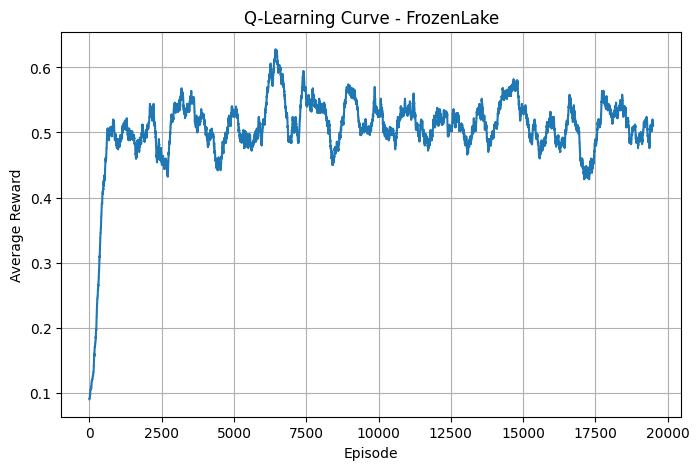

In [11]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------
print("Name:Ranjan Kumar G")
print("Reg N:212223240138")
window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()